In [82]:
import pandas as pd
from CCA_utils import *

## Baseline Model Panel

In [90]:
study_sovereigns = [
    'Saudi Arabia', 'Abu Dhabi', 'Dubai', 'Qatar', 'Colombia',
    'Mexico', 'Brazil', 'Egypt', 'Malaysia','Indonesia', 'Philippines', 'Turkey', 'Chile', 'China',
    'South Africa', 'South Korea', 'Thailand']

cca_panel_df = pd.read_csv('../data/processed/CCA/cca_newfx_rates.csv')
cca_panel_df['date'] = pd.to_datetime(cca_panel_df['date'])
cca_panel_df = cca_panel_df[cca_panel_df['country'].isin(study_sovereigns)].copy()
cca_panel_df.drop(columns=['cds_spread_1Y'], inplace=True)
cca_panel_df.rename(columns={'cds_spread_5Y': 'cds_spread'}, inplace=True)


T=1.0
vol_window = 52
freq = 'W'

cca_panel_df['domestic_rate_in_units'] = cca_panel_df['domestic_rate_in_units']/100
cca_panel_df['risk_free_rate'] = cca_panel_df['risk_free_rate']/100
cca_panel_df['monetary_base_mn_localcurr'] = cca_panel_df['monetary_base_mn_localcurr'] / 1000
cca_panel_df['domestic_debt_bn_localcurr'] = cca_panel_df['domestic_debt_bn_localcurr']
cca_panel_df['external_debt_mn_usd'] = cca_panel_df['external_debt_mn_usd']/1000

## Model 1: Specific data

In [91]:

#Join oil prices and oil futures
oil_prices = pd.read_csv('../data/processed/Oil/oil_prices_datastream.csv')
oil_prices['date'] = pd.to_datetime(oil_prices['date'])
oil_futures = pd.read_csv('../data/processed/Oil/oil_futures.csv')
oil_futures['date'] = pd.to_datetime(oil_futures['date'])

cca_panel_df = cca_panel_df.merge(oil_prices[['date','Brent']], on='date', how='left')
cca_panel_df = cca_panel_df.merge(oil_futures[['date','Brent_24m']],on='date',how='left')

oil_prod = pd.read_csv('../data/processed/Oil/crude_oil_production.csv')
oil_prod = oil_prod.rename(columns={oil_prod.columns[0]: 'country'})
oil_prod = oil_prod.melt(id_vars='country', var_name='year', value_name='oil_production_Mt_yr')
oil_prod['year'] = oil_prod['year'].astype(int)

# UAE for Abu Dhabi and Dubai
uae = oil_prod[oil_prod['country'] == 'United Arab Emirates'].copy()
for name in ['Abu Dhabi', 'Dubai']:
    rows = uae.copy()
    rows['country'] = name
    oil_prod = pd.concat([oil_prod, rows], ignore_index=True)

cca_panel_df['year'] = cca_panel_df['date'].dt.year
cca_panel_df = cca_panel_df.merge(oil_prod[['year', 'country', 'oil_production_Mt_yr']], 
                                   on=['country', 'year'], how='left')
cca_panel_df['oil_production_Mt_yr'] = cca_panel_df['oil_production_Mt_yr'].fillna(0)
cca_panel_df['oil_production_Mt_yr'] = cca_panel_df['oil_production_Mt_yr'].astype(int)

cca_panel_df.set_index(['date','country'], inplace=True)
cca_panel_df = (
    cca_panel_df
    .groupby('country')
    .resample(freq, level='date')
    .last()
)
cca_panel_df.reset_index(inplace=True)
cca_panel_df

/var/folders/wy/gjw_3_n51t748hfngpz4zf0w0000gn/T/ipykernel_75615/797547017.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  oil_prices['date'] = pd.to_datetime(oil_prices['date'])
/var/folders/wy/gjw_3_n51t748hfngpz4zf0w0000gn/T/ipykernel_75615/797547017.py:5: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  oil_futures['date'] = pd.to_datetime(oil_futures['date'])


,country,date,Unnamed: 0,year,quarter,month,week,cds_spread,msci_index,monetary_base_mn_localcurr,domestic_debt_bn_localcurr,external_debt_mn_usd,domestic_rate_in_units,risk_free_rate,fx_rate,Brent,Brent_24m,oil_production_Mt_yr
0,Abu Dhabi,2014-01-05,13776,2014,1.0,1.0,1.0,56.31999,749.581,288.310000,210.154,22.889480,0.01,0.0013,3.672960,107.07,97.38,170
1,Abu Dhabi,2014-01-12,13777,2014,1.0,1.0,2.0,55.85999,771.135,288.310000,210.154,22.889480,0.01,0.0012,3.672960,106.33,97.76,170
2,Abu Dhabi,2014-01-19,13778,2014,1.0,1.0,3.0,55.32999,777.754,288.310000,210.154,22.889480,0.01,0.0011,3.672960,106.89,97.58,170
3,Abu Dhabi,2014-01-26,13779,2014,1.0,1.0,4.0,55.34999,808.655,288.310000,210.154,22.889480,0.01,0.0011,3.672960,107.45,98.29,170
4,Abu Dhabi,2014-02-02,13780,2014,1.0,1.0,5.0,56.32999,804.960,288.310000,210.154,22.889480,0.01,0.0010,3.672960,107.13,97.10,170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9753,Turkey,2024-12-01,13197,2024,4.0,11.0,48.0,251.12000,610.455,6067.888530,10716.668,157.127935,0.50,0.0430,34.722222,73.20,68.68,6
9754,Turkey,2024-12-08,13198,2024,4.0,12.0,49.0,241.90000,610.777,6585.275534,10716.668,157.127935,0.50,0.0419,34.722222,72.19,68.20,6
9755,Turkey,2024-12-15,13199,2024,4.0,12.0,50.0,247.11000,644.678,6585.275534,10716.668,157.127935,0.50,0.0424,34.965035,74.16,69.80,6
9756,Turkey,2024-12-22,13200,2024,4.0,12.0,51.0,256.52000,626.599,6585.275534,10716.668,157.127935,0.50,0.0427,35.211268,72.83,68.45,6


In [110]:
results = pd.DataFrame()
eta = 1

for country, group in cca_panel_df.groupby('country'):

    df = group.copy().sort_values('date').reset_index(drop=True)
        
    # --- Unit conversions ---
    r_d = df['domestic_rate_in_units']
    r_f = df['risk_free_rate']
    M_bn = df['monetary_base_mn_localcurr']
    dom_D_bn = df['domestic_debt_bn_localcurr']
    ext_D_bn = df['external_debt_mn_usd']
    fx_rate = df['fx_rate']


    # --- LCL$ ---
    df['LCL_usd'] = [
        compute_lcl_usd(m, bd, fx, rd, rf, T)
        for m, bd, fx, rd, rf in zip(
            M_bn, dom_D_bn, fx_rate, r_d, r_f
        )
    ]

        # --- Barrier ---
    df['B_f'] = [
            compute_barrier_kvm(debt, rf, T)
            for debt, rf in zip(
                df['external_debt_mn_usd'], r_f
            )
        ]

    df['futures_term'] = (df['Brent']/df['Brent_24m']) ** eta
    df['LCL_aug'] = df['LCL_usd'] * df['futures_term']


    ann_factor = np.sqrt(52) if freq == 'W' else np.sqrt(12)
    log_ret = np.log(df['LCL_aug'] / df['LCL_aug'].shift(1))
    
    df['sigma_lcl'] = log_ret.rolling(window=vol_window).std() * ann_factor

    # --- Solve CCA with augmented LCL ---
    out = {k: [] for k in ['implied_V', 'implied_sigma_V', 'cca_converged',
                            'distance_to_distress', 'default_prob',
                            'model_spread_bps', 'put_value', 'risky_debt',
                            'leverage']}

    for i, row in df.iterrows():
        cca = solve_CCA(row['LCL_aug'], row['sigma_lcl'], row['B_f'],
                        r_f.iloc[i], T)
        risk = compute_risk(cca['V'], cca['sigma_V'], row['B_f'],
                           r_f.iloc[i], T)

        out['implied_V'].append(cca['V'])
        out['implied_sigma_V'].append(cca['sigma_V'])
        out['cca_converged'].append(cca['converged'])
        out['distance_to_distress'].append(risk['d2'])
        out['default_prob'].append(risk['default_prob'])
        out['model_spread_bps'].append(risk['credit_spread_bps'])
        out['put_value'].append(risk['put_value'])
        out['risky_debt'].append(risk['risky_debt'])
        out['leverage'].append(risk['leverage'])

    for col, vals in out.items():
        df[col] = vals

    results = pd.concat([results, df])


START_DATE = '2020-01-01'
END_DATE = '2024-12-31'

results = results[
    (results['date'] >= START_DATE) & (results['date'] <= END_DATE)
].copy()


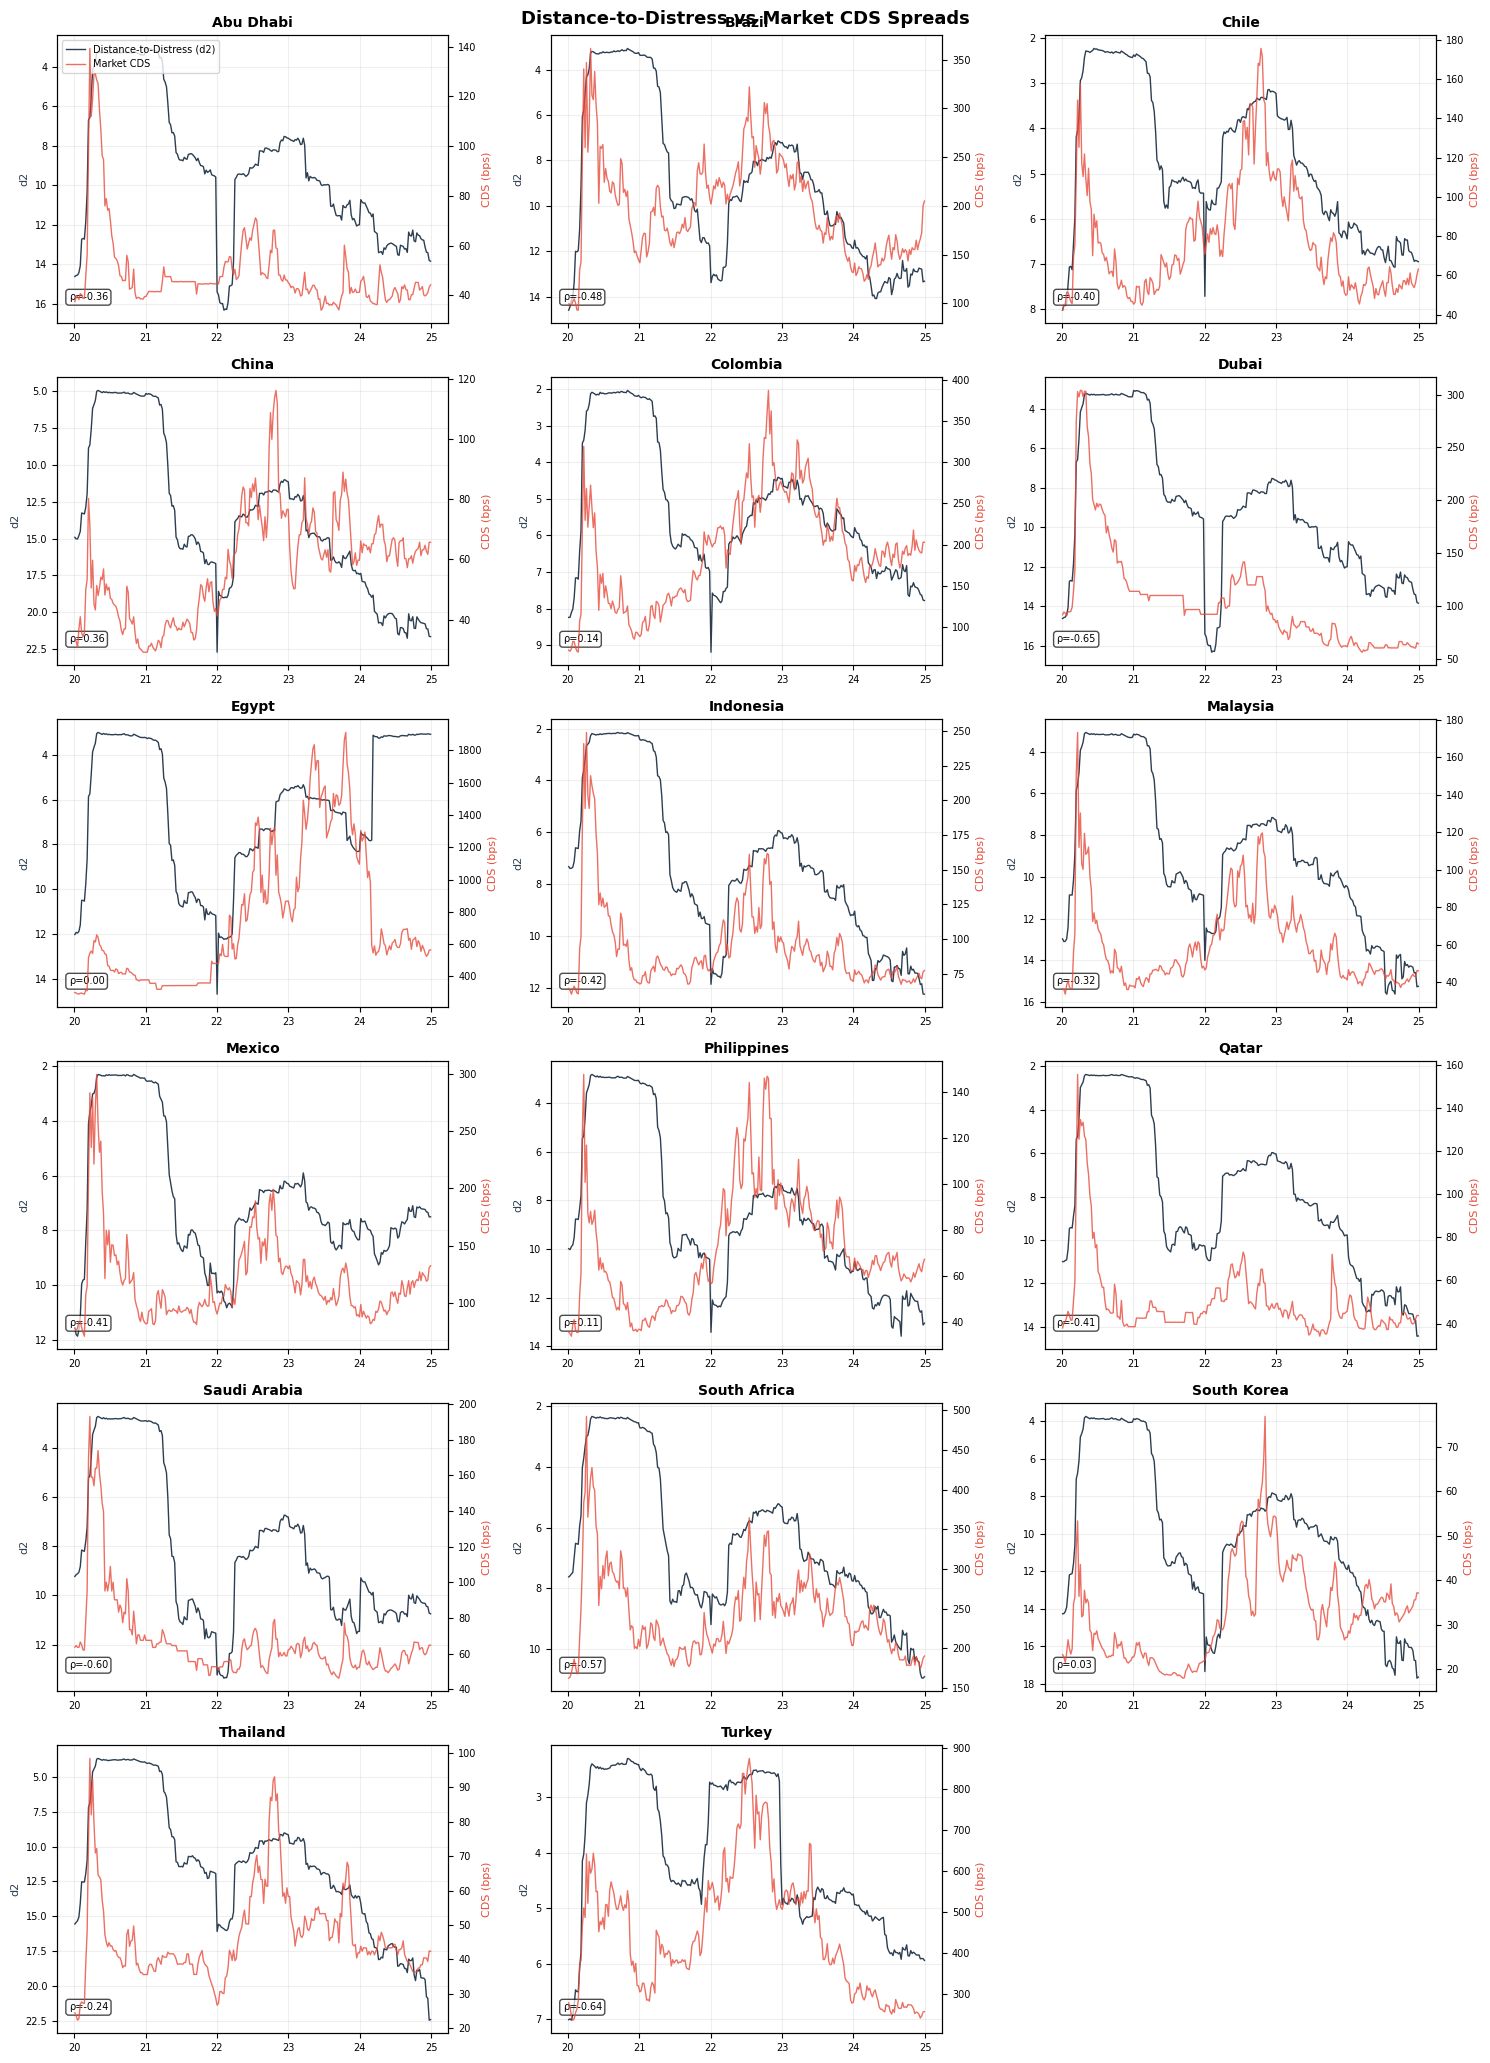

In [111]:
d2_vs_cds = plot_d2_vs_cds(results)

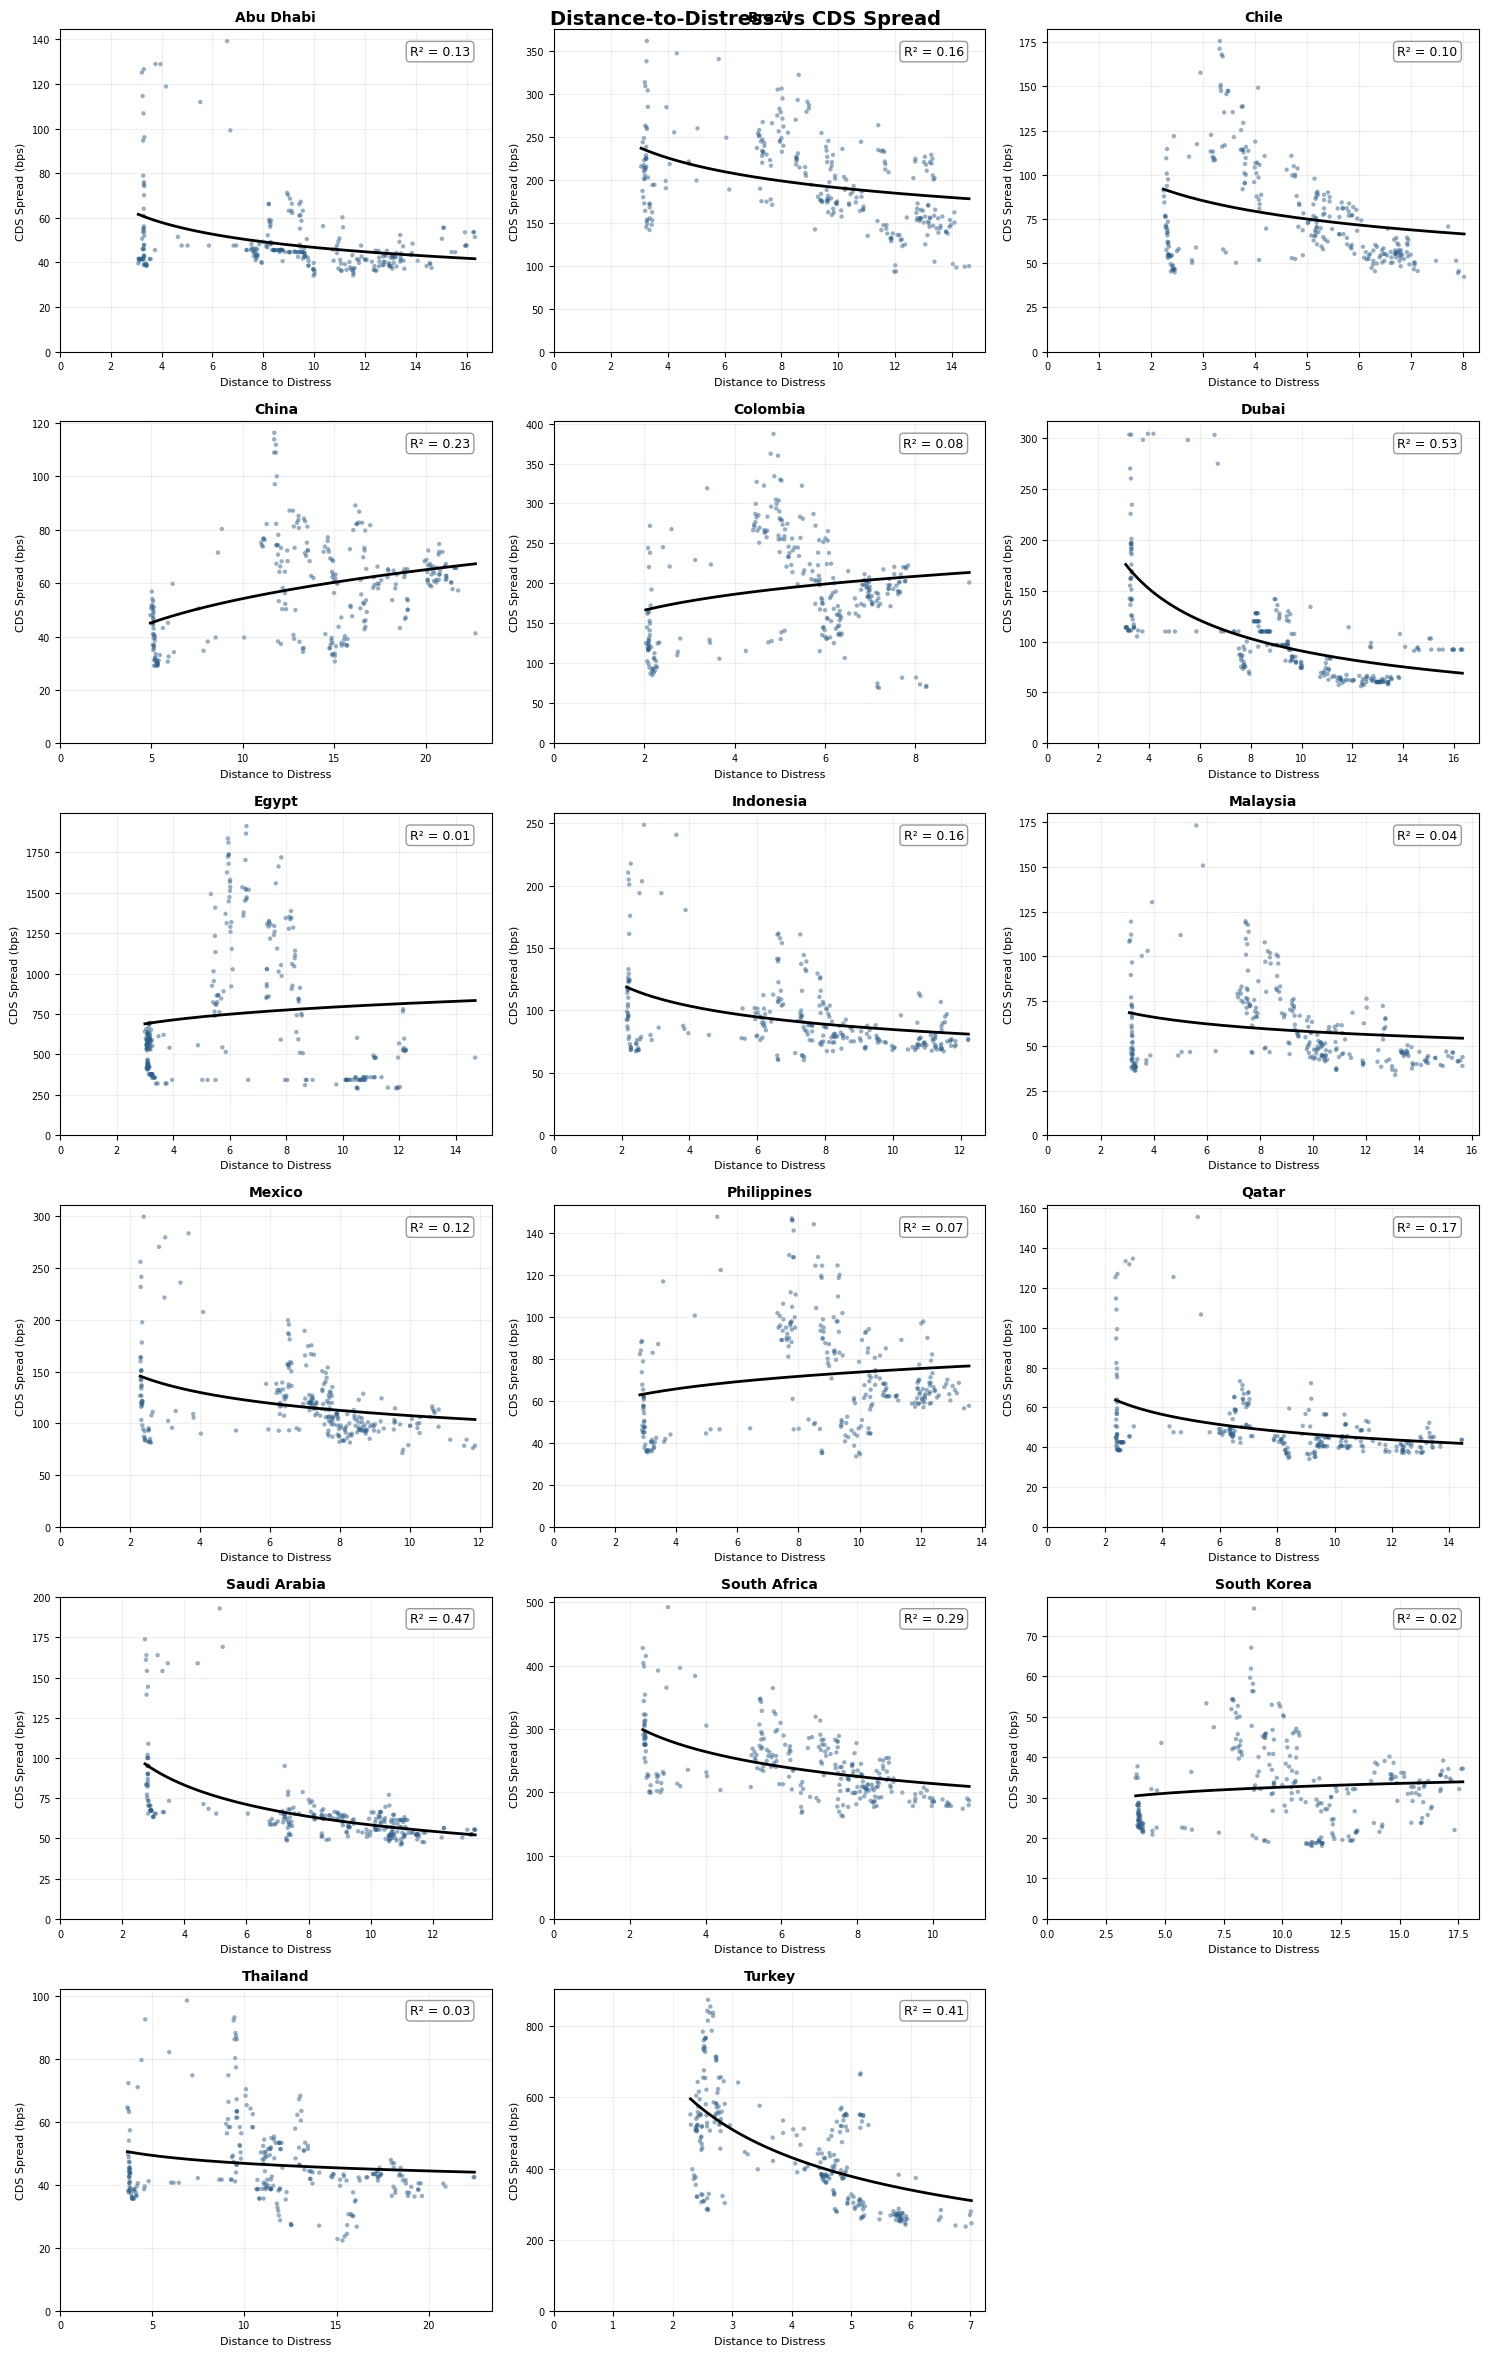

In [112]:
d2_scatter = plot_d2_scatter(results)

In [106]:
display, raw = correlation_table(
    results,
    dd_col='distance_to_distress',
    horizons=[1, 4, 12],
    horizon_labels=['1w', '1m', '3m'],
)
display

,Country,N,ρ (1w),Dir (1w),ρ (1m),Dir (1m),ρ (3m),Dir (3m)
0,Abu Dhabi,261,-0.09,57%,-0.10,55%,-0.11*,53%
1,Brazil,261,-0.26***,59%,-0.30***,64%,-0.34***,66%
2,Chile,261,-0.08,58%,-0.09,56%,-0.24***,63%
3,China,261,-0.06,58%,-0.03,57%,-0.12*,62%
4,Colombia,261,-0.14**,61%,-0.15**,64%,-0.35***,72%
5,Dubai,261,-0.21***,55%,-0.10,56%,-0.14**,54%
6,Egypt,261,-0.03,52%,-0.10*,60%,-0.15**,55%
7,Indonesia,261,-0.05,63%,0.01,59%,-0.18***,65%
8,Malaysia,261,-0.15**,56%,-0.10,62%,-0.31***,61%
9,Mexico,261,-0.15**,60%,-0.24***,66%,-0.45***,72%


In [ ]:
results.to_csv("../output/results/M1_results.csv")